In [1]:
import nifti_utils
import dicom_utils
import nibabel as nib
import numpy as np
import skimage
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
from sklearn import metrics
import os
import pandas as pd
import pydicom
import xgboost as xgb
import math
import utils

In [2]:
DATA_FOLDER = "/media/bendico765/Crucial X9/mama-mia"
ORIGINAL_ISPY2_FOLDER = "/media/bendico765/EXTERNAL_US/ISPY2/manifest-1641168072464/ISPY2"

# Data analysis

## Pre-constrast phase identification

Per identificare correttamente la fase pre contrasto del dataset non curato e quella pre constrasto del dataset curato si prendono i voxel delle ROI e si confrontano, per verificare che siano uguali

In [3]:
def check_volumes_equivalence(uncurated_dce, curated_dce, slice_start, slice_end):
    results = []
    for i in range(slice_start, slice_end+1):
        b = curated_dce[i]
        a = uncurated_dce[i+7]
        
        windows = sliding_window_view(a, b.shape)
        
        results.append(np.any((windows==b).all(axis=(2,3))))

    return results

### Using NIFTI Vibrant with no phase indication

In [4]:
# get the first phase and roi from the curated dataset
patient_id = "ISPY2_100899"
lesions_df = pd.read_csv(f"{DATA_FOLDER}/lesions.csv", index_col=0)
curated_dce = nifti_utils.get_ispy2_image(lesions_df.loc()[patient_id]["Multiphase 1 path"])
curated_roi, z_indexes, y_indexes, x_indexes = nifti_utils.get_ispy2_mask(lesions_df.loc()[patient_id]["Roi mask Filepath"])

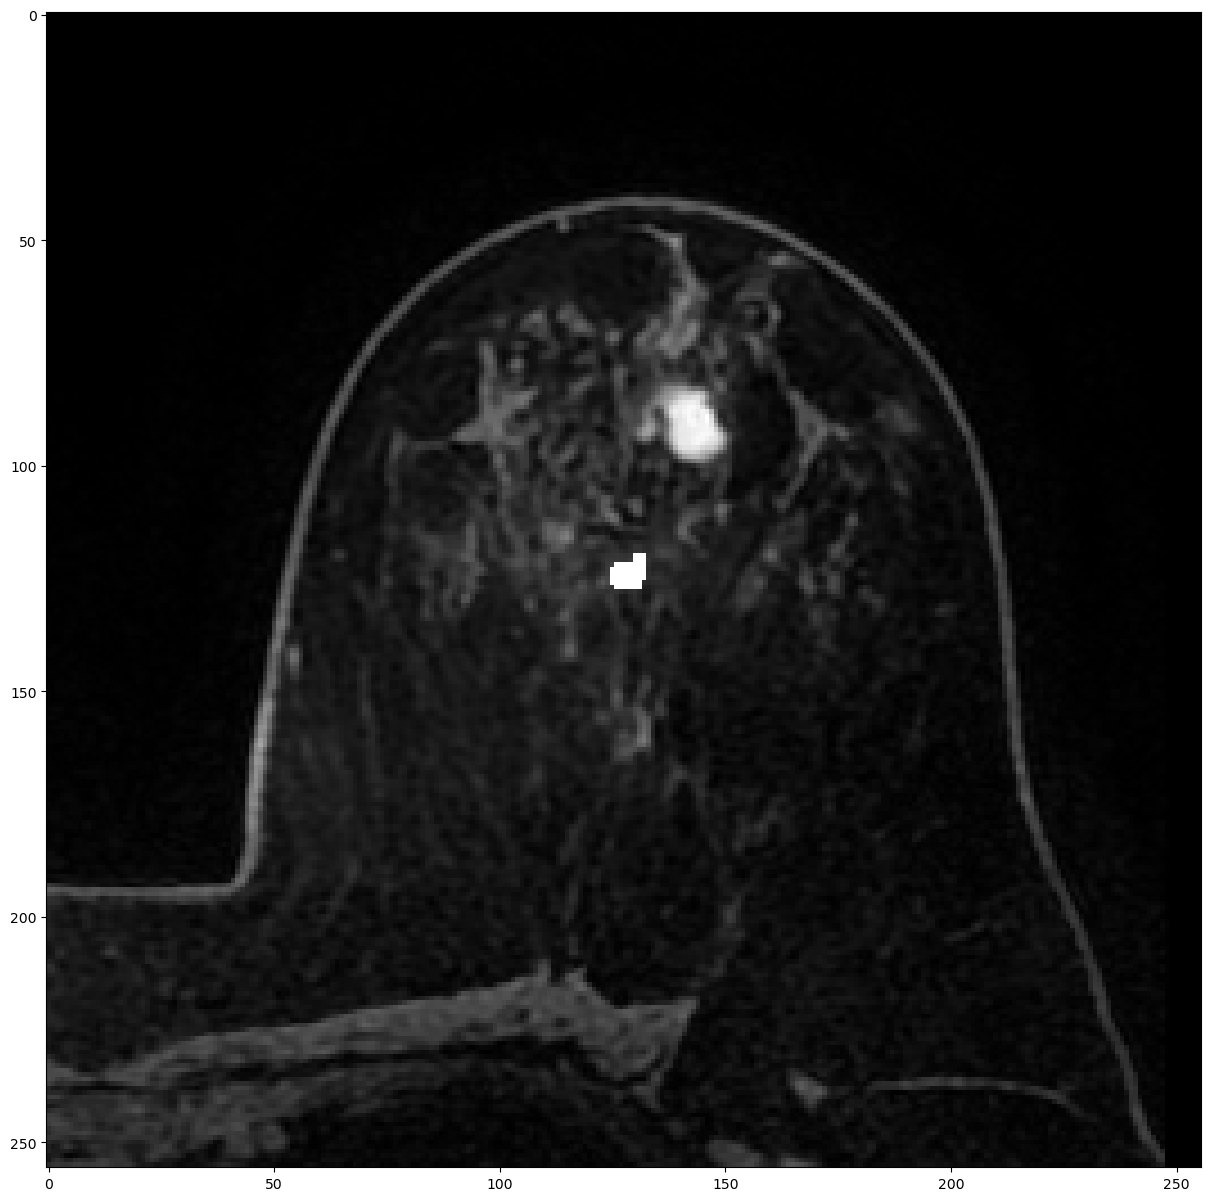

In [5]:
z = 47
nifti_utils.plot_image(curated_dce[z], curated_roi[z])

Uncurated dataset file: /media/bendico765/EXTERNAL_US/ISPY2/manifest-1641168072464/ISPY2/ISPY2-100899/10-26-2002-100899T0-ISPY2MRIT0-88595/500.000000-ISPY2 AX VIBRANT-SERIES-52523


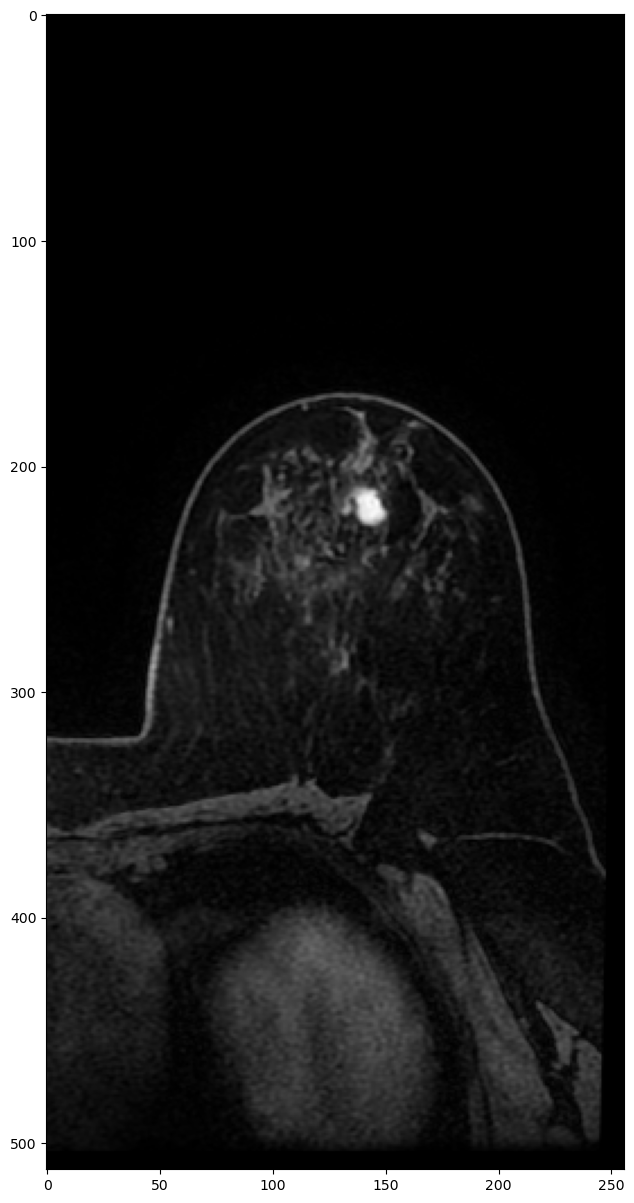

In [6]:
filepath = "/media/bendico765/EXTERNAL_US/ISPY2/manifest-1641168072464/ISPY2/ISPY2-100899/10-26-2002-100899T0-ISPY2MRIT0-88595/500.000000-ISPY2 AX VIBRANT-SERIES-52523"

# load the non curated dataset
print(f"Uncurated dataset file: {filepath}")

dicom_slices = dicom_utils.read_dicomdir(filepath)
volume_3d = dicom_utils.get_3d_shape(dicom_slices)

plt.figure(figsize=(15, 15))
plt.imshow(volume_3d[z+7,:,256:], cmap=plt.cm.gray)

In [7]:
curated_z = 47
uncurated_z = curated_z+7
#print(z_indexes)
# curated_dce (80,256,256)
# curated_roi (80,256,256)
# volume_3d (106,512,512)

check_volumes_equivalence(volume_3d, curated_dce, 47, 49)

[np.True_, np.True_, np.True_]

# Data preparation

In [4]:
lesions_df = nifti_utils.get_ispy2_dataset(DATA_FOLDER)
lesions_df.to_csv(f"{DATA_FOLDER}/lesions.csv", index=0)

In [3]:
patient_id = "ISPY2-103693"
dce_paths = nifti_utils.get_ispy2_dce_paths(ORIGINAL_ISPY2_FOLDER, patient_id)

results = []
for dce_path in dce_paths:
    filename = os.listdir(dce_path)[0]
    print(f"{dce_path}/{filename}")
    results.append(pydicom.dcmread(f"{dce_path}/{filename}").TemporalResolution)

/media/bendico765/EXTERNAL_US/ISPY2/manifest-1641168072464/ISPY2/ISPY2-103693/04-01-2004-103693T0-ISPY2MRIT0-60619/501.000000-ISPY2 Ph1AX VIBRANT-SERIES-20179/1-01.dcm


AttributeError: 'FileDataset' object has no attribute 'TemporalResolution'

In [4]:
temporal_resolutions_df = nifti_utils.get_ispy2_temporal_resolutions(DATA_FOLDER, ORIGINAL_ISPY2_FOLDER)

In [5]:
temporal_resolutions_df

,Patient ID,TemporalResolution 1,TemporalResolution 2,TemporalResolution 3,TemporalResolution 4,TemporalResolution 5,TemporalResolution 6
0,ISPY2-100899,NaN,NaN,91463.0,91499.0,91500.0,91500.0
1,ISPY2-102011,NaN,NaN,NaN,NaN,NaN,NaN
2,ISPY2-102212,NaN,NaN,NaN,NaN,NaN,NaN
3,ISPY2-103693,NaN,NaN,95076.0,95004.0,95003.0,94998.0
4,ISPY2-103939,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
975,ISPY2-994987,NaN,NaN,NaN,NaN,NaN,NaN
976,ISPY2-995480,NaN,NaN,NaN,NaN,NaN,NaN
977,ISPY2-997702,NaN,NaN,NaN,NaN,NaN,NaN
978,ISPY2-999264,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# getting all the lesions information in a structured dataset
lesions_df = nifti_utils.get_ispy2_dataset(DATA_FOLDER)
lesions_df.to_csv(f"{DATA_FOLDER}/lesions.csv", index=0)

# computing the temporal resolutions
temporal_resolutions_df = nifti_utils.get_ispy2_temporal_resolutions(DATA_FOLDER, ORIGINAL_ISPY2_FOLDER)

# keeping only those patients which have temporal resolutions information
#temporal_resolutions_df = temporal_resolutions_df[temporal_resolutions_df["TemporalResolution 2"].notnull()]
temporal_resolutions_df
#temporal_resolutions_df.to_csv(f"{DATA_FOLDER}/temporal_resolutions.csv", index=0)

AttributeError: 'FileDataset' object has no attribute 'TemporalResolution'

In [ ]:
get

## Dynamic information extraction

In [4]:
dynamic_df = pd.DataFrame(
    nifti_utils.get_ispy2_dynamic_information(f"{DATA_FOLDER}/lesions.csv", f"{DATA_FOLDER}/temporal_resolutions.csv"),
    columns = [
        "Patient id", 
        "max_derivative_phase_2",
        "max_derivative_phase_3",
        "max_derivative_phase_4",
        "max_derivative_phase_5",
        "mean_derivative_phase_2",
        "mean_derivative_phase_3",
        "mean_derivative_phase_4",
        "mean_derivative_phase_5",
        "median_derivative_phase_2",
        "median_derivative_phase_3",
        "median_derivative_phase_4",
        "median_derivative_phase_5",
        "std_derivative_phase_2",
        "std_derivative_phase_3",
        "std_derivative_phase_4",
        "std_derivative_phase_5",
    ]
)
dynamic_df.to_csv(f"{DATA_FOLDER}/original_dynamic.csv", index=0)
dynamic_df

,Patient id,max_derivative_phase_2,max_derivative_phase_3,max_derivative_phase_4,max_derivative_phase_5,mean_derivative_phase_2,mean_derivative_phase_3,mean_derivative_phase_4,mean_derivative_phase_5,median_derivative_phase_2,median_derivative_phase_3,median_derivative_phase_4,median_derivative_phase_5,std_derivative_phase_2,std_derivative_phase_3,std_derivative_phase_4,std_derivative_phase_5
0,ISPY2_100899,0.005215,0.004284,0.000885,0.000656,0.003778,0.003698,0.001419,0.000540,0.003335,0.003978,0.001585,0.000710,0.001231,0.000468,-0.000111,-0.000146
1,ISPY2_103693,0.009414,0.005905,0.000474,-0.000084,0.005818,0.003325,0.000514,0.000385,0.005638,0.003631,0.000621,0.000400,0.001692,0.000566,-0.000114,-0.000126
2,ISPY2_104384,0.002619,0.000831,-0.000150,-0.000127,0.000319,0.000160,0.000057,0.000037,0.000138,0.000035,0.000035,0.000035,0.000319,0.000197,0.000043,0.000010
3,ISPY2_109874,0.008899,0.003117,0.000132,0.000091,0.005754,0.001563,-0.000134,0.000239,0.005811,0.001797,-0.000020,0.000284,0.002343,0.000809,0.000191,-0.000167
4,ISPY2_111004,0.004003,0.000337,-0.000232,-0.000093,0.002078,0.000354,0.000012,-0.000050,0.002095,0.000430,-0.000012,-0.000070,0.000658,-0.000098,-0.000079,-0.000051
5,ISPY2_111646,0.002013,0.000591,0.000150,-0.000197,0.000679,0.000258,0.000116,0.000069,0.000625,0.000289,0.000127,0.000081,0.000203,0.000097,0.000020,0.000008
6,ISPY2_111881,0.015870,0.001650,-0.001510,-0.000742,0.011242,0.000188,0.000085,-0.000536,0.011700,-0.000165,-0.000061,-0.000536,0.002203,-0.000454,-0.000487,-0.000057
7,ISPY2_114087,0.009716,-0.001690,-0.000667,-0.000537,0.003783,0.000472,-0.000053,-0.000109,0.003779,0.000537,-0.000060,-0.000149,0.000756,-0.000070,-0.000002,-0.000032
8,ISPY2_117424,0.023867,0.003918,-0.000711,-0.000485,0.015647,0.001905,0.000327,-0.000409,0.015908,0.001877,0.000454,-0.000325,0.003009,0.000016,0.000015,-0.000096
9,ISPY2_122579,0.001535,0.002350,0.001598,0.000858,0.018350,0.003027,-0.000177,-0.001023,0.019999,0.002685,-0.000574,-0.001365,0.004310,-0.000224,-0.000237,-0.000286


# Model inference on new data

## ISPY2

In [3]:
dynamic_df = pd.read_csv(f"{DATA_FOLDER}/original_dynamic.csv", index_col=0)
dynamic_df

,max_derivative_phase_2,max_derivative_phase_3,max_derivative_phase_4,max_derivative_phase_5,mean_derivative_phase_2,mean_derivative_phase_3,mean_derivative_phase_4,mean_derivative_phase_5,median_derivative_phase_2,median_derivative_phase_3,median_derivative_phase_4,median_derivative_phase_5,std_derivative_phase_2,std_derivative_phase_3,std_derivative_phase_4,std_derivative_phase_5
Patient id,,,,,,,,,,,,,,,,
ISPY2_100899,0.005215,0.004284,0.000885,0.000656,0.003778,0.003698,0.001419,0.000540,0.003335,0.003978,0.001585,0.000710,0.001231,0.000468,-0.000111,-0.000146
ISPY2_103693,0.009414,0.005905,0.000474,-0.000084,0.005818,0.003325,0.000514,0.000385,0.005638,0.003631,0.000621,0.000400,0.001692,0.000566,-0.000114,-0.000126
ISPY2_104384,0.002619,0.000831,-0.000150,-0.000127,0.000319,0.000160,0.000057,0.000037,0.000138,0.000035,0.000035,0.000035,0.000319,0.000197,0.000043,0.000010
ISPY2_109874,0.008899,0.003117,0.000132,0.000091,0.005754,0.001563,-0.000134,0.000239,0.005811,0.001797,-0.000020,0.000284,0.002343,0.000809,0.000191,-0.000167
ISPY2_111004,0.004003,0.000337,-0.000232,-0.000093,0.002078,0.000354,0.000012,-0.000050,0.002095,0.000430,-0.000012,-0.000070,0.000658,-0.000098,-0.000079,-0.000051
ISPY2_111646,0.002013,0.000591,0.000150,-0.000197,0.000679,0.000258,0.000116,0.000069,0.000625,0.000289,0.000127,0.000081,0.000203,0.000097,0.000020,0.000008
ISPY2_111881,0.015870,0.001650,-0.001510,-0.000742,0.011242,0.000188,0.000085,-0.000536,0.011700,-0.000165,-0.000061,-0.000536,0.002203,-0.000454,-0.000487,-0.000057
ISPY2_114087,0.009716,-0.001690,-0.000667,-0.000537,0.003783,0.000472,-0.000053,-0.000109,0.003779,0.000537,-0.000060,-0.000149,0.000756,-0.000070,-0.000002,-0.000032
ISPY2_117424,0.023867,0.003918,-0.000711,-0.000485,0.015647,0.001905,0.000327,-0.000409,0.015908,0.001877,0.000454,-0.000325,0.003009,0.000016,0.000015,-0.000096


### Kinetic curves

In [4]:
def plot_patient_kinetic_curves(lesions_df, patient_id):
    """
    Plot the maximum/mean/median/std of intensity values of the specified patient lesion
    """
    multiphase_filepaths = [
        lesions_df.loc()[patient_id][f"Multiphase {i} path"]
        for i in range(1,6)
    ]
    roi_filepath = lesions_df.loc()[patient_id]["Roi mask Filepath"]
    max_values, mean_values, median_values, std_values = nifti_utils.get_ispy2_patient_intensity_values(multiphase_filepaths, roi_filepath)

    fig, axes = plt.subplots(4,1, figsize=(10,15))
    fig.suptitle(f"{patient_id} Multiphase")
    
    axes[0].plot(["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5"], max_values)
    axes[0].set_title("Max")
    
    axes[1].plot(["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5"], mean_values)
    axes[1].set_title("Mean")
    
    axes[2].plot(["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5"], median_values)
    axes[2].set_title("Median")
    
    axes[3].plot(["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5"], std_values)
    axes[3].set_title("Standard deviation")

def plot_lineplot(ax, x, y, y_std, label, color):
    ax.plot(x, y, label=label)
    ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.2)

def plot_aggregate_kinetic_curves(lesions_df):
    """
    Plot a lineplot with the aggregate maximum/mean/median/std of intensity values of all the lesions,
    with mean and standard deviation
    """
    intensity_values = {
        "phase_1": {
            "maximum": [],
            "mean": [],
            "median": [],
            "std": []
        },
        "phase_2": {
            "maximum": [],
            "mean": [],
            "median": [],
            "std": []
        },
        "phase_3": {
            "maximum": [],
            "mean": [],
            "median": [],
            "std": []
        },
        "phase_4": {
            "maximum": [],
            "mean": [],
            "median": [],
            "std": []
        },
        "phase_5": {
            "maximum": [],
            "mean": [],
            "median": [],
            "std": []
        }
    }
    
    f = lambda row: nifti_utils.get_ispy2_patient_intensity_values([row[f"Multiphase {i} path"] for i in range(1,6)],row["Roi mask Filepath"])
    for _, row in lesions_df.iterrows():
        maximum, mean, median, std = f(row)
    
        for i, value in enumerate(maximum):
            intensity_values[f"phase_{i+1}"]["maximum"].append(value)
    
        for i, value in enumerate(mean):
            intensity_values[f"phase_{i+1}"]["mean"].append(value)
    
        for i, value in enumerate(median):
            intensity_values[f"phase_{i+1}"]["median"].append(value)
    
        for i, value in enumerate(std):
            intensity_values[f"phase_{i+1}"]["std"].append(value)
    
    fig, axes = plt.subplots(4,1, figsize=(10,15))
    fig.suptitle("MultiPhase aggregated values")
    
    x = ["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5"]
    
    # maximum plot
    plot_lineplot(
        axes[0],
        x,
        y = np.array([
            np.mean(intensity_values["phase_1"]["maximum"]),
            np.mean(intensity_values["phase_2"]["maximum"]),
            np.mean(intensity_values["phase_3"]["maximum"]),
            np.mean(intensity_values["phase_4"]["maximum"]),
            np.mean(intensity_values["phase_5"]["maximum"])
        ]),
        y_std = np.array([
            np.std(intensity_values["phase_1"]["maximum"]),
            np.std(intensity_values["phase_2"]["maximum"]),
            np.std(intensity_values["phase_3"]["maximum"]),
            np.std(intensity_values["phase_4"]["maximum"]),
            np.std(intensity_values["phase_5"]["maximum"])
        ]),
        label = "Tumor",
        color = "blue"
    )
    axes[0].set_title("Max")
    axes[0].legend(loc='upper right')
    
    # mean plot
    plot_lineplot(
        axes[1],
        x,
        y = np.array([
            np.mean(intensity_values["phase_1"]["mean"]),
            np.mean(intensity_values["phase_2"]["mean"]),
            np.mean(intensity_values["phase_3"]["mean"]),
            np.mean(intensity_values["phase_4"]["mean"]),
            np.mean(intensity_values["phase_5"]["mean"])
        ]),
        y_std = np.array([
            np.std(intensity_values["phase_1"]["mean"]),
            np.std(intensity_values["phase_2"]["mean"]),
            np.std(intensity_values["phase_3"]["mean"]),
            np.std(intensity_values["phase_4"]["mean"]),
            np.std(intensity_values["phase_5"]["mean"])
        ]),
        label = "Tumor",
        color = "blue"
    )
    axes[1].set_title("Mean")
    axes[1].legend(loc='upper right')
    
    # median plot
    plot_lineplot(
        axes[2],
        x,
        y = np.array([
            np.mean(intensity_values["phase_1"]["median"]),
            np.mean(intensity_values["phase_2"]["median"]),
            np.mean(intensity_values["phase_3"]["median"]),
            np.mean(intensity_values["phase_4"]["median"]),
            np.mean(intensity_values["phase_5"]["median"])
        ]),
        y_std = np.array([
            np.std(intensity_values["phase_1"]["median"]),
            np.std(intensity_values["phase_2"]["median"]),
            np.std(intensity_values["phase_3"]["median"]),
            np.std(intensity_values["phase_4"]["median"]),
            np.std(intensity_values["phase_5"]["median"])
        ]),
        label = "Tumor",
        color = "blue"
    )
    axes[2].set_title("Median")
    axes[2].legend(loc='upper right')
    
    # median plot
    plot_lineplot(
        axes[3],
        x,
        y = np.array([
            np.mean(intensity_values["phase_1"]["std"]),
            np.mean(intensity_values["phase_2"]["std"]),
            np.mean(intensity_values["phase_3"]["std"]),
            np.mean(intensity_values["phase_4"]["std"]),
            np.mean(intensity_values["phase_5"]["std"])
        ]),
        y_std = np.array([
            np.std(intensity_values["phase_1"]["std"]),
            np.std(intensity_values["phase_2"]["std"]),
            np.std(intensity_values["phase_3"]["std"]),
            np.std(intensity_values["phase_4"]["std"]),
            np.std(intensity_values["phase_5"]["std"])
        ]),
        label = "Tumor",
        color = "blue"
    )
    axes[3].set_title("Std")
    axes[3].legend(loc='upper right')

In [4]:
temporal_resolutions_df = pd.read_csv(f"{DATA_FOLDER}/temporal_resolutions.csv")

# restrinct lesion analysis to only those lesions that have a temporal resolution, i.e. those that will be actually used
lesions_df = pd.read_csv(f"{DATA_FOLDER}/lesions.csv", index_col=0)

common_index = lesions_df.index.intersection([s.replace("-", "_") for s in temporal_resolutions_df.set_index("Patient ID").index])
lesions_df = lesions_df.loc[common_index]

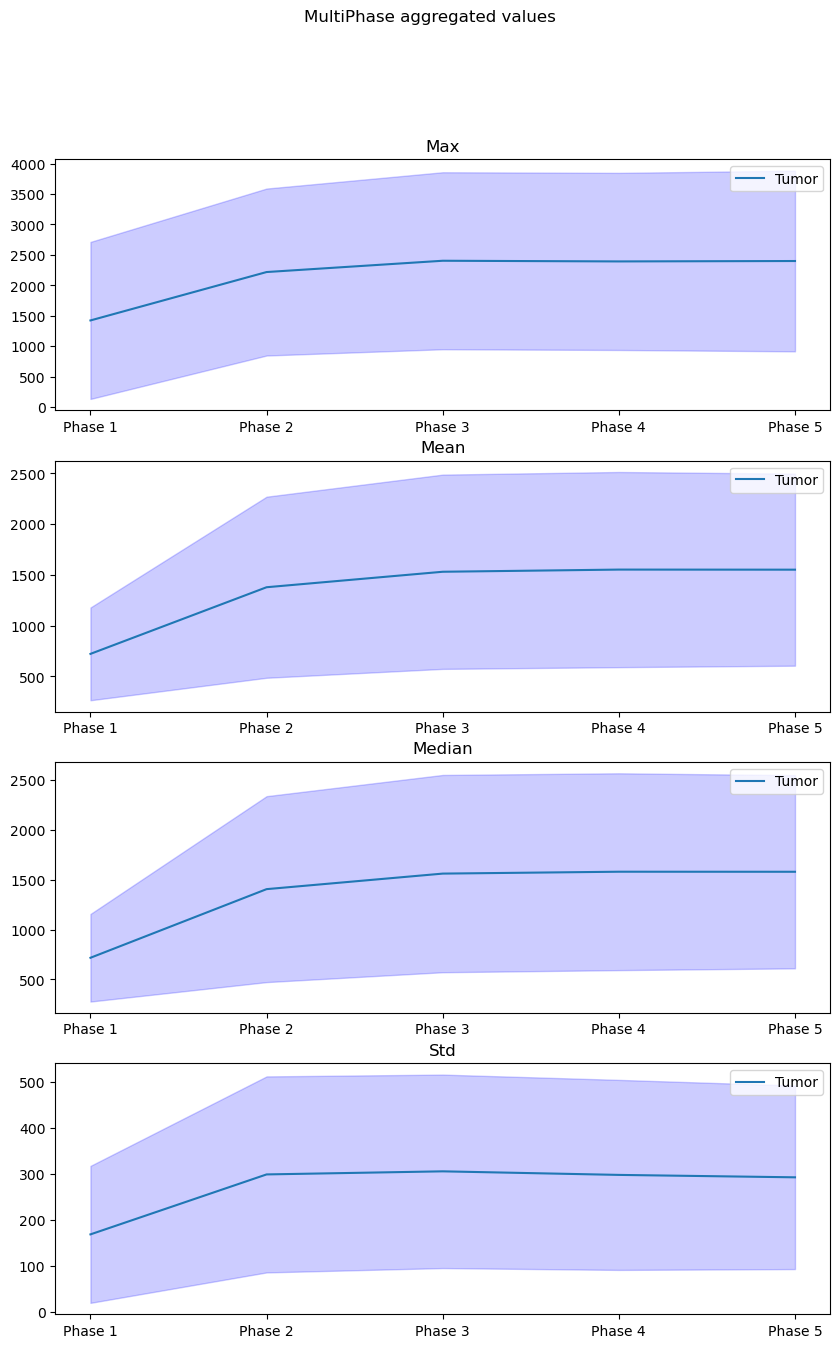

In [6]:
plot_aggregate_kinetic_curves(lesions_df)

#### Patient 100899

In [5]:
lesions_df.head(1)

,Multiphase 1 path,Multiphase 2 path,Multiphase 3 path,Multiphase 4 path,Multiphase 5 path,Multiphase 6 path,Roi mask Filepath
Patient ID,,,,,,,
ISPY2_100899,/media/bendico765/Crucial X9/mama-mia/images/I...,/media/bendico765/Crucial X9/mama-mia/images/I...,/media/bendico765/Crucial X9/mama-mia/images/I...,/media/bendico765/Crucial X9/mama-mia/images/I...,/media/bendico765/Crucial X9/mama-mia/images/I...,/media/bendico765/Crucial X9/mama-mia/images/I...,/media/bendico765/Crucial X9/mama-mia/segmenta...


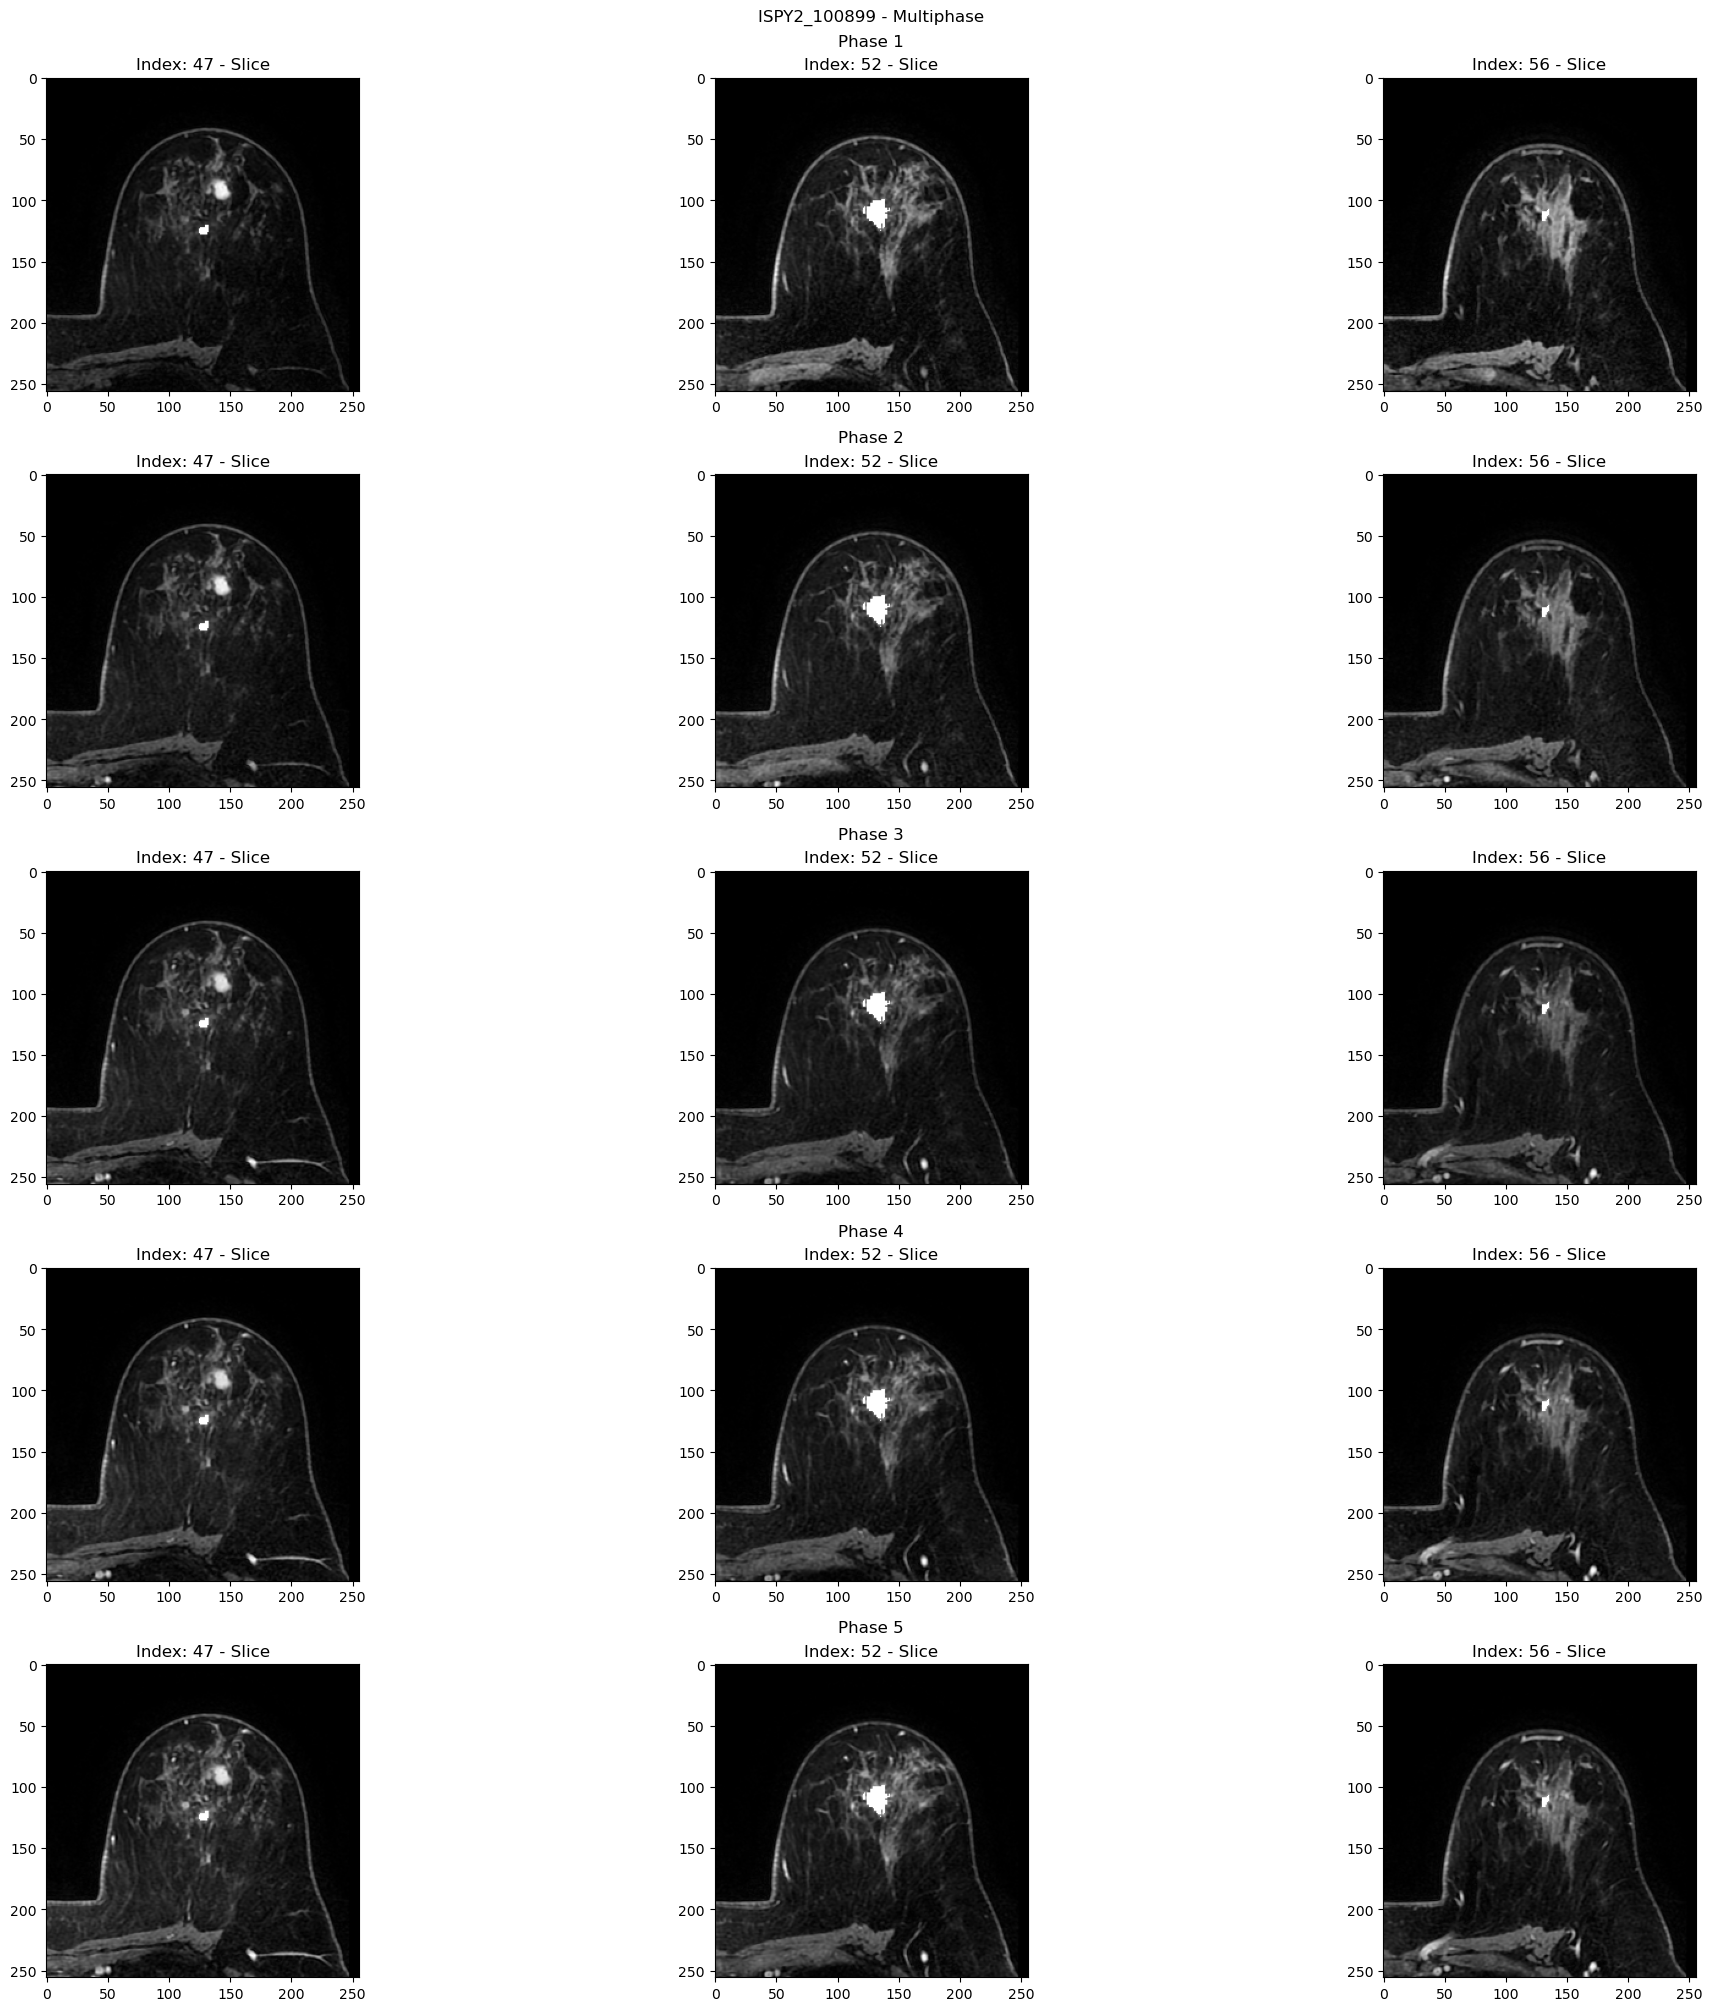

In [25]:
def plot_dce_with_masks(lesions_df: pd.DataFrame, patient_id: str):
    #fig, axes = plt.subplots(5,3, figsize=(15,15))
    #fig.suptitle(f"{patient_id} - MultiPhase")

    roi, z_indexes, y_indexes, x_indexes = nifti_utils.get_ispy2_mask(lesions_df.loc()[patient_id]["Roi mask Filepath"])
    z_beg = z_indexes[0]
    z_mid = z_indexes[math.floor(len(z_indexes)/2)]
    z_end = z_indexes[-1]

    """
    for i in range(1,6):   
        dce = nifti_utils.get_ispy2_image(lesions_df.loc()[patient_id][f"Multiphase {i} path"])

        for j, z in enumerate([z_beg, z_mid, z_end]):
            max_intensity = np.max(dce[z])
            axes[i-1, j].imshow(
                np.where(roi[z] != 0, max_intensity, dce[z]),
                cmap = plt.cm.gray
            )
    """
    fig = plt.figure(constrained_layout=True, figsize=(20,20))
    fig.suptitle(f'{patient_id} - Multiphase')
    
    # create 5x1 subfigs
    subfigs = fig.subfigures(nrows=5, ncols=1)
    for row, subfig in enumerate(subfigs):
        subfig.suptitle(f'Phase {row+1}')
        dce = nifti_utils.get_ispy2_image(lesions_df.loc()[patient_id][f"Multiphase {row+1} path"])
    
        # create 1x3 subplots per subfig
        axs = subfig.subplots(nrows=1, ncols=3)
        for ax, z in zip(axs, [z_beg, z_mid, z_end]):
            max_intensity = np.max(dce[z])
            ax.imshow(
                np.where(roi[z] != 0, max_intensity, dce[z]),
                cmap = plt.cm.gray
            )
            ax.set_title(f'Index: {z} - Slice')
        """
        for col, ax in enumerate(axs):
            ax.plot()
            ax.set_title(f'Plot title {col}')
        """
    
patient_id = "ISPY2_100899"
plot_dce_with_masks(lesions_df, patient_id)

In [26]:
(roi[z] > 0).astype(float)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [33]:
(roi[z] > 0).astype(float)[120,130]

np.float64(0.0)

In [73]:
import nibabel as nib
filepath = lesions_df.loc()[patient_id]["Roi mask Filepath"]

mask = nib.load(filepath)
array = mask.get_fdata()
array = np.transpose(array, (2,1,0))
array = array[:, ::-1, ::-1]

In [75]:
array.nonzero()

(array([47, 47, 47, ..., 56, 56, 56]),
 array([120, 120, 120, ..., 116, 116, 116]),
 array([130, 131, 132, ..., 130, 131, 132]))

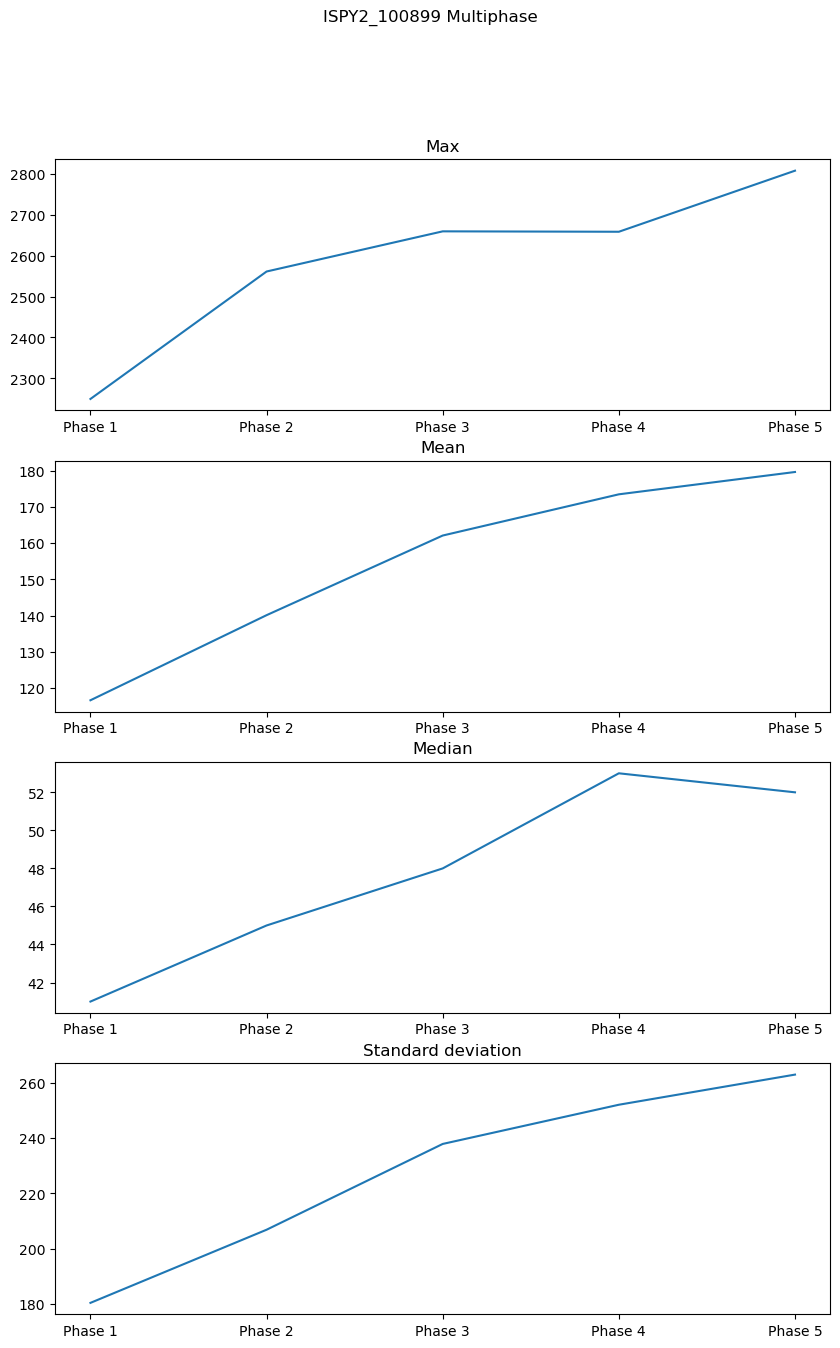

In [14]:
patient_id = "ISPY2_100899"
plot_patient_kinetic_curves(lesions_df, patient_id)

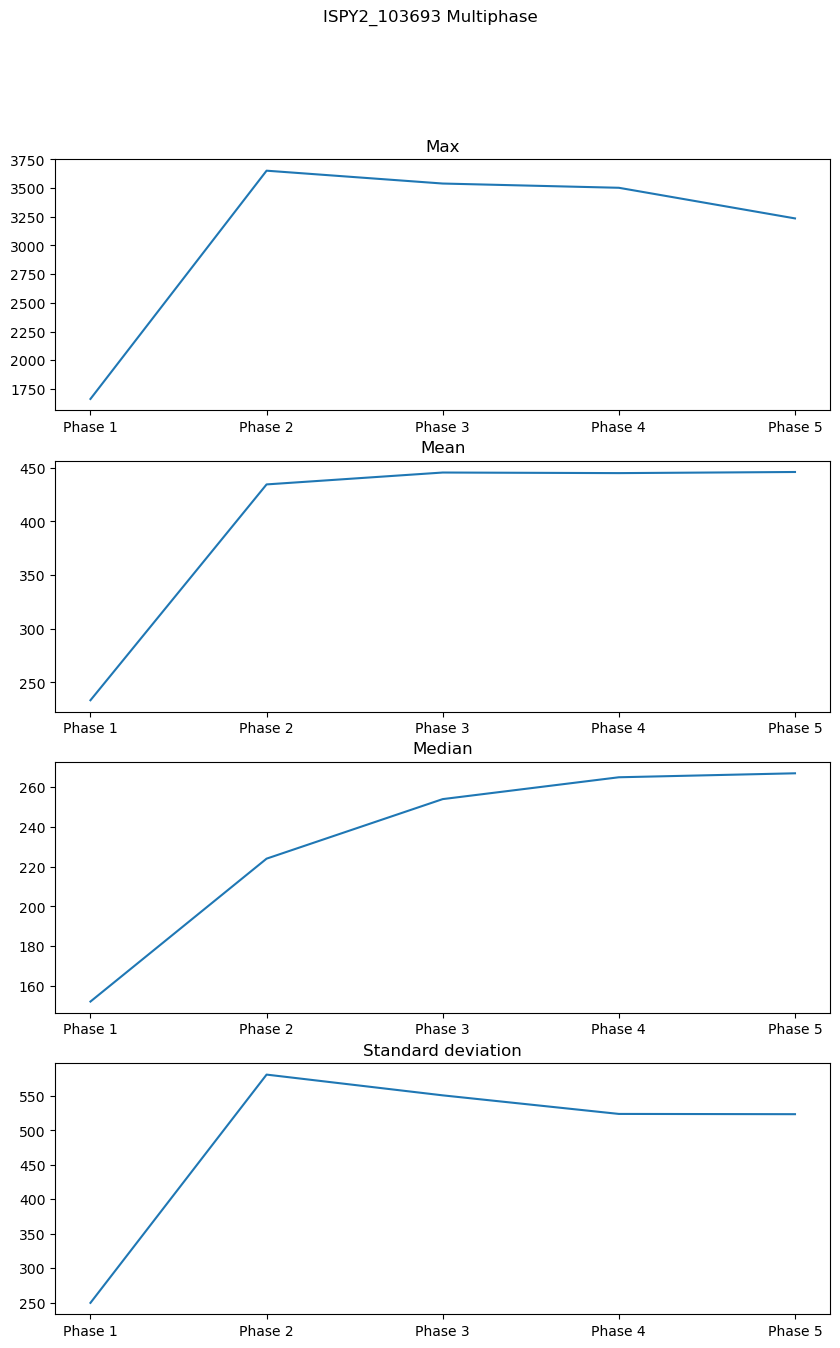

In [51]:
patient_id = "ISPY2_103693"
plot_patient_kinetic_curves(lesions_df, patient_id)

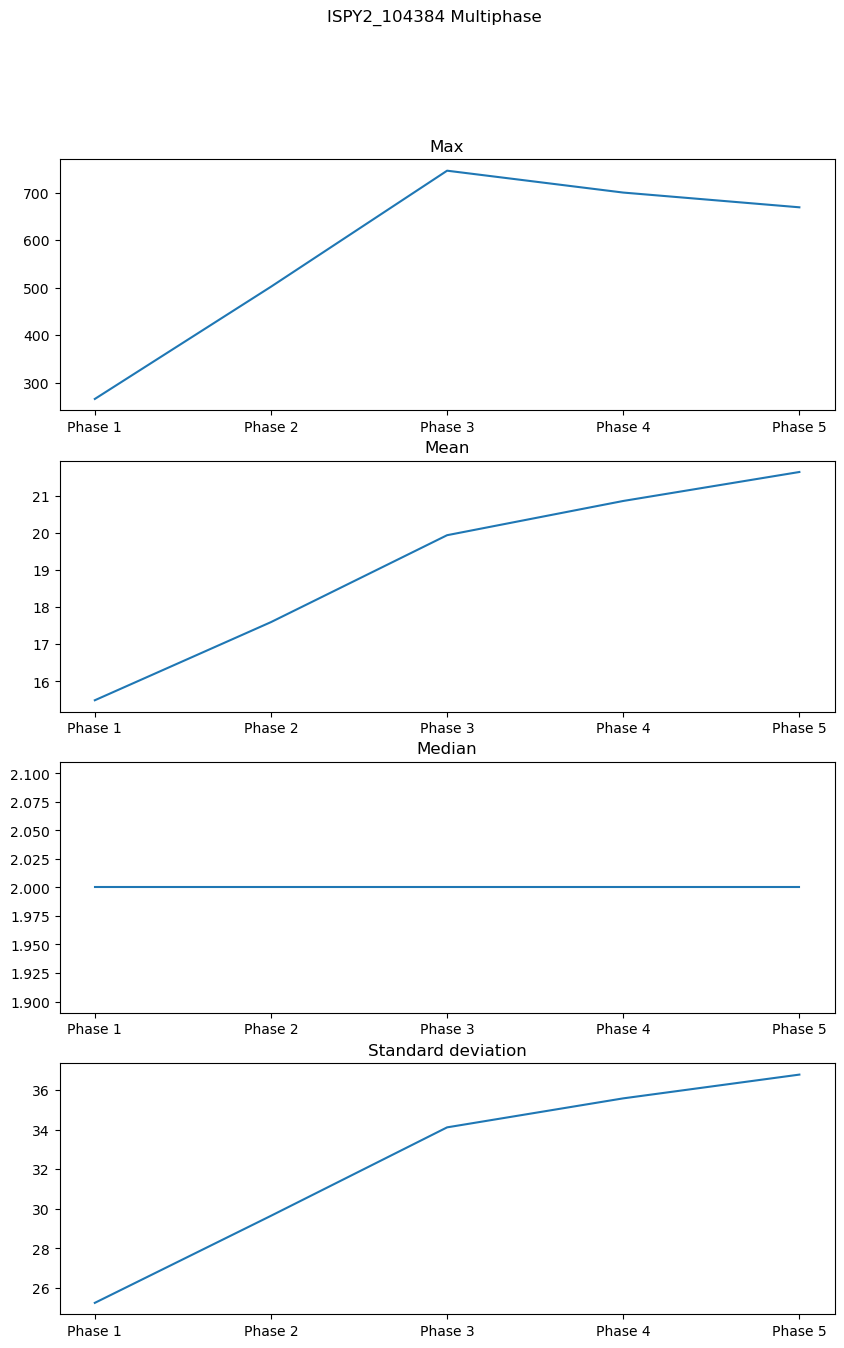

In [52]:
patient_id = "ISPY2_104384"
plot_patient_kinetic_curves(lesions_df, patient_id)

### Prediction

In [8]:
clfs = []
predictions = []

X = dynamic_df.to_numpy()

# load all models and classify instances
for i in range(5):
    bst = xgb.XGBClassifier(eval_metric=metrics.roc_auc_score)
    bst.load_model(f"/media/bendico765/Crucial X9/MRI Lesions/models/dynamic/original/model{i}.model")
    clfs.append(bst)

    y_predicted = bst.predict_proba(X)
    predictions.append(y_predicted)   

In [9]:
predictions = np.array(predictions)
predictions = np.sum(predictions,axis=0)/len(clfs)
metrics.accuracy_score([1 for _ in range(len(predictions))], np.argmax(predictions, axis=1))

0.5333333333333333

In [12]:
predictions

array([[0.65178645, 0.34821355],
       [0.55982697, 0.4401731 ],
       [0.7251833 , 0.27481672],
       [0.5427672 , 0.4572327 ],
       [0.07530848, 0.92469156],
       [0.8441076 , 0.15589234],
       [0.14015593, 0.8598441 ],
       [0.05248395, 0.9475161 ],
       [0.13552745, 0.8644725 ],
       [0.353461  , 0.64653903],
       [0.14246838, 0.85753155],
       [0.08096944, 0.91903055],
       [0.33732828, 0.6626717 ],
       [0.6998557 , 0.3001443 ],
       [0.7396773 , 0.26032266]], dtype=float32)